# Fixed-node architecture comparison

Three things vary across the runs on this page, and every figure holds two of them fixed:

| | |
|---|---|
| **model type** | the aggregation architecture — mean, pointwise MLP, MPNN complete, MPNN, GT |
| **model ablation** | within one architecture, which inputs it gets — position, LPE, both, neither |
| **node count** | within one ablation, how many embeddings the neighborhood holds — 10, 20, 40 |

Every run uses its best available epoch (maximum window-level macro F1), whether or not training has finished. This notebook reads small CSV/JSON files only.

**Folds are averaged automatically.** Every figure goes through `mean_over_folds`, which collapses the runs of one model (same architecture, same ablation, same node count) trained on different `split_seed`s into a single row: the mean of their scores, the sample standard deviation across them as an error bar, and a `folds` column saying how many went in. A second fold therefore changes these figures by existing on disk and nothing else, and the titles say which splits are behind them.

**Right now that is one fold** — `fold_0`, a single 80/20 split of whole cells at `split_seed` 0 — so every score below is a single-fold estimate, every `_std` is NaN, no error bars are drawn, and a margin between two models is a margin on that one split. Differences smaller than a run's own epoch-to-epoch wobble are not resolvable until there is a second fold to average with.

**Per-class scores are computed from each run's confusion matrix**, not read off `epoch_metrics.csv`. The CSV carries recall and precision only at the finest level, and neither combines upward into a coarser hierarchy class without the counts behind it — so `best_metrics.json` (written at the same best epoch, and present for every started run) is what the class dropdowns are built from. `payload_epoch` records which epoch that payload actually holds.

In [1]:
# Auto-reload the analysis modules on every cell run. Without it, editing
# analysis/all_windows/*.py has no effect until the kernel restarts: Python caches modules
# in sys.modules, so re-running this import cell re-imports the OLD object and a
# newly added name fails with ImportError rather than appearing.
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'results' / 'all_windows').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from analysis.all_windows.architecture_comparison import (
    architecture_grid_selector, class_names, confusion_grid_selector, fold_label,
    load_best_epochs, load_confusions, mean_over_folds, plot_across_counts,
    plot_within_count)

RESULTS = ROOT / 'results' / 'all_windows'
payloads = load_confusions(RESULTS)
df = load_best_epochs(RESULTS, payloads)
print(f'{len(df)} started runs; {int(df.complete.sum()) if len(df) else 0} finished; {fold_label(df)}')
print('hierarchy classes, breadth-first:', *class_names(payloads), sep='\n  ')
display(df[['architecture','model','n_embeddings','fold','best_epoch','payload_epoch',
            'epochs_available','complete','window_macro_f1']])

81 started runs; 51 finished; fold_0
hierarchy classes, breadth-first:
  neuron
  non_neuron
  excitatory
  inhibitory
  pyramidal
  thalamocortical
  putative_cge
  putative_parvalbumin
  putative_somatostatin
  astrocyte
  microglia
  oligo


,architecture,model,n_embeddings,fold,best_epoch,payload_epoch,epochs_available,complete,window_macro_f1
0,GT L2,GT L2,10,0,2,2,16,True,0.832938
1,GT L2,GT L2 + LPE,10,0,5,5,16,True,0.839858
2,GT L2,GT L2 + position,10,0,2,2,16,True,0.833614
3,GT L2,GT L2 + position + LPE,10,0,8,8,16,True,0.839566
4,GT L4,GT L4,10,0,2,2,16,True,0.834971
...,...,...,...,...,...,...,...,...,...
76,MPNN complete L4,MPNN complete L4 + position,40,0,3,3,6,False,0.891643
77,MPNN complete L4,MPNN complete L4 + position + LPE,40,0,4,4,7,False,0.899293
78,Mean,Mean,40,0,12,12,16,True,0.888529
79,Pointwise MLP L2,Pointwise MLP L2,40,0,10,10,16,True,0.900865


## 1. Every model at each node count

One bar per model, averaged over its folds. The error bar and the `±` on each label are the spread across folds, and appear only where a model has more than one.

,architecture,model,n_embeddings,folds,complete,window_macro_f1,window_macro_f1_std,cell_macro_f1,cell_macro_f1_std
0,GT L2,GT L2,10,1,True,0.832938,NaN,0.971157,NaN
1,GT L2,GT L2,20,1,True,0.860635,NaN,0.952811,NaN
2,GT L2,GT L2,40,1,True,0.897969,NaN,0.957074,NaN
3,GT L2,GT L2 + LPE,10,1,True,0.839858,NaN,0.977990,NaN
4,GT L2,GT L2 + LPE,20,1,True,0.866902,NaN,0.969576,NaN
...,...,...,...,...,...,...,...,...,...
76,Pointwise MLP L2,Pointwise MLP L2,20,1,True,0.869703,NaN,0.971250,NaN
77,Pointwise MLP L2,Pointwise MLP L2,40,1,True,0.900865,NaN,0.973527,NaN
78,Pointwise MLP L4,Pointwise MLP L4,10,1,True,0.829360,NaN,0.963709,NaN
79,Pointwise MLP L4,Pointwise MLP L4,20,1,True,0.873761,NaN,0.977990,NaN


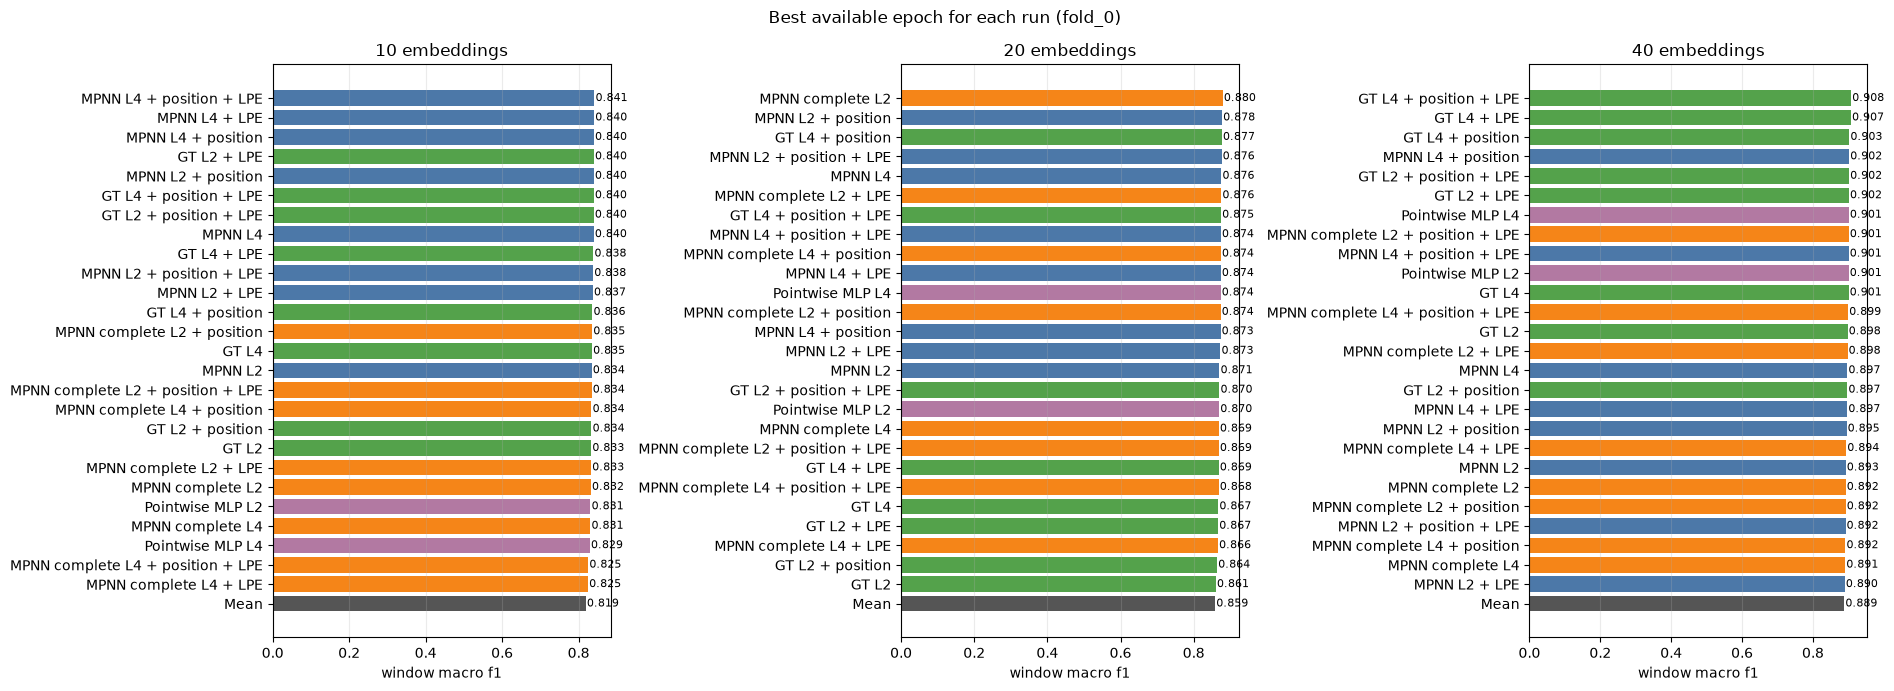

In [2]:
summary = mean_over_folds(df)
display(summary[['architecture','model','n_embeddings','folds','complete',
                 'window_macro_f1','window_macro_f1_std','cell_macro_f1','cell_macro_f1_std']])
plot_within_count(df);

## 2. How each model type improves as the node count grows

One panel per **model type**, one line per **model ablation**, **node count** on x. A panel therefore answers "does this ablation keep paying as the neighborhood grows", and comparing panels answers "does that answer depend on the aggregation".

**The class dropdown reaches every class of the hierarchy, breadth-first.** `neuron` and `non_neuron` come first, then `excitatory` and `inhibitory`, then the eight classes the head actually emits — indented by depth. A coarse selection is scored by summing the confusion matrix's block for that node, so a thalamocortical window predicted pyramidal counts as a correct `excitatory` call and a wrong `pyramidal` one. Nothing is re-run to ask the coarser question; it is exact, because the model's output is already a finest-level code.

`Level` switches between the window scores the checkpoint is selected on and the cell scores the majority vote produces. `Metric` picks F1, recall or precision, all of which resolve to the macro/balanced form when no class is selected — and per-class accuracy resolves to recall, which is what it is by definition.

**The class dropdown stops at the level-2 hierarchy here**, because a confusion matrix is all these runs publish and it is already at that level. The granular breakdown — `L4IT`, `AltBasket`, `NMC` — needs per-window predictions joined to the manifest's labels, which lives in `feature_prediction_correlation.ipynb` (its section 7 is the per-granular-class bar chart across node counts).

In [3]:
architecture_grid_selector(df, payloads)

Output()

## 3. Confusion matrices across node count

Pick a **model type**, then one of its **ablations** — the second dropdown names the two input switches this sweep varies, **position** and **LPE**, rather than repeating the architecture. The **node counts** are the grid, `n` increasing to the right, so the diagonal moving (or not) with neighborhood size is read across the row.

Matrices appear once a run publishes `best_metrics.json`, which the sweep writes whenever a run's best epoch improves — a still-training run is included at its current best epoch, and a count with no run yet keeps an empty panel rather than shifting its neighbours over.

Row normalization puts each class's recall on the diagonal and puts every panel on the same 0–1 scale; without it the panels carry raw window counts that differ by node count, so a cell's colour would say more about how many windows the count produced than about the model. The flat-softmax run (`gnn_flat_scratch_*`) is reachable here and nowhere else on this page: it differs by classification objective rather than by aggregation, so it is marked `(flat softmax)` and kept out of every comparison above.

In [4]:
confusion_grid_selector(payloads)

Output()